In [1]:
import os
os.listdir('.')

['zeta_zeros_N5000_dps50.npy',
 'ldelta_zeros_N1455_dps80_partial.npy',
 '-PROMPT-v6-DATASET.md',
 '.config',
 'ldh_zeros_N5000_dps50.npy',
 '.kernel_llm_logs_1.txt',
 'memory',
 'lchi5_zeros_N5000_dps80.npy',
 '.prompts']

In [2]:
import numpy as np
import mpmath as mp

zeta = np.load('zeta_zeros_N5000_dps50.npy')
ldh = np.load('ldh_zeros_N5000_dps50.npy')
lchi5 = np.load('lchi5_zeros_N5000_dps80.npy')
ldelta = np.load('ldelta_zeros_N1455_dps80_partial.npy')

for name, arr in [('zeta',zeta),('ldh',ldh),('lchi5',lchi5),('ldelta',ldelta)]:
 print(name, arr.shape, arr.dtype, arr[0], arr[-1])

zeta (5000,) <U51 14.134725141734693790457251983562470270784257115699 5447.8619983012998564121586734642921676829672006076
ldh (5000,) <U51 5.0941598445710949256987955170797974750670744531091 4981.1674898625791053105083724292317970900546075558
lchi5 (5000,) <U81 6.6484533447277147161232784599793178472985854232444983723747129467 4388.2090125941801377592509179068522248538541759189201573787539145
ldelta (1455,) <U81 9.2223793999211025222437671927434781355287706224320092899981864280019212953707290 1095.8905568079281792848599941778506664840443308606502951853687094242569554427745


In [3]:
# Convert to float64 - we don't need extreme precision for number variance statistics
zeros = {
 'zeta': np.array([float(s) for s in zeta]),
 'L_DH': np.array([float(s) for s in ldh]),
 'L(chi5)':np.array([float(s) for s in lchi5]),
 'L(Delta)':np.array([float(s) for s in ldelta]),
}
for k,v in zeros.items():
 print(k, v.shape, v.min(), v.max(), 'sorted?', np.all(np.diff(v)>=0))

zeta (5000,) 14.134725141734695 5447.8619983012995 sorted? True
L_DH (5000,) 5.094159844571095 4981.167489862579 sorted? True
L(chi5) (5000,) 6.648453344727715 4388.20901259418 sorted? True
L(Delta) (1455,) 9.222379399921103 1095.890556807928 sorted? True


In [4]:
# Unfolding via smooth N(T) for each L-function.
# Standard mean density: N(T) ~ (T/(2*pi)) * log(T/(2*pi*Q)) - T/(2*pi) + ...
# Conductor / Q depends on function. Use:
# zeta: Q = 1, degree d=1. N(T) ~ (T/2π) log(T/(2πe))
# L(chi5): degree d=1, conductor q=5. N(T) ~ (T/2π) log(5T/(2πe))
# L_DH: degree d=2 functional eqn (Davenport-Heilbronn). Actually L_DH is a degree-2 L-function-like object (not Euler, but functional equation degree 2). The standard counting:
# N(T) ~ (d*T/(2π)) log(T/(2πe)) + (T/(2π)) log(Q)
# For L_DH conductor "Q=5" approx. Hmm. Let's just use degree 2.
# L(Delta,s): weight 12 cusp form -> shift Hardy normalization. Counting: N(T) ~ (T/π) log(T/(2π e)) (degree 2, level 1). The completed L-function L*(s) = (2π)^{-s} Γ(s + 11/2) L(Δ,s). The trick: zeros are usually expressed with imaginary part of s where centerline s=1/2. Standard mean density at height T for L(Δ,s) using analytic conductor: 
# N(T) ~ (T/π) log( T/(2π) ) + correction.
#
# To do unfolding accurately and consistently, the cleanest approach is empirical unfolding: replace each γ_i by its rank i (smoothed). The "unfolded spacings" are simply 1 by definition if using rank. So that's not useful.
# Better: use the local mean density d(T) = dN/dT and define unfolded zeros as ξ_i = N_smooth(γ_i). Then spacings have mean 1.

# Let me implement smooth N(T) per function:
import math

def Nsmooth_zeta(T):
 if T<=0: return 0.0
 return (T/(2*math.pi))*math.log(T/(2*math.pi)) - T/(2*math.pi) + 7/8

def Nsmooth_lchi5(T):
 # degree 1, conductor 5, even/odd? real quadratic char mod 5 -> chi(-1)=1, so even, a=0.
 # Riemann-von Mangoldt for Dirichlet L-functions:
 # N(T) = (T/2π) log(qT/(2π e)) + O(log(qT))
 if T<=0: return 0.0
 q=5
 return (T/(2*math.pi))*math.log(q*T/(2*math.pi)) - T/(2*math.pi)

def Nsmooth_ldh(T):
 # Davenport-Heilbronn: degree 2 functional equation with conductor 5
 # N(T) ~ (2T/2π) log(T sqrt(q)/(2π e)) ... use general formula
 # General: N(T) ~ (T/π) log(T/(2π)) * (d/2) + ... 
 # For degree d, conductor q:
 # N(T) = (d T/(2π)) log(T/(2π)) - (d T/(2π)) + (T/(2π)) log q + O(log T)
 if T<=0: return 0.0
 d=2; q=5
 return (d*T/(2*math.pi))*math.log(T/(2*math.pi)) - d*T/(2*math.pi) + (T/(2*math.pi))*math.log(q)

def Nsmooth_ldelta(T):
 # L(Delta,s) degree 2, level 1, weight 12. Conductor in analytic sense for cusp form weight k: there's a shift but to leading order:
 # N(T) ~ (T/π) log(T/(2π)) - T/π + correction from Gamma(s+11/2)
 # More accurately using completed Λ(s) = (2π)^{-s} Γ(s+11/2) L(Δ,s), the mean density at large T is:
 # dN/dT = (1/π) log(T/(2π)) + (1/(2π)) * [terms from Γ'/Γ at (1/2 + iT + 11/2)] ≈ (1/π) log T for large T but at small T corrections matter
 # Use d=2, but with the Gamma shift the analytic conductor is more like T^2 * something. Let's use the general modular form formula:
 # For a weight-k cusp form on SL2(Z): N(T) ~ (T/π) log(T/(2πe)) + (k-1)/(2π) * T * ?? 
 # Simpler: use Stirling-based local density: d(T) = (1/(2π))*[2*log(T/(2π)) + Re(ψ(1/2 + iT + (k-1)/2)) + ...]. For large T this ~ (1/π) log T but with offset.
 # Use mpmath digamma for precision:
 import mpmath as _mp
 if T<=0: return 0.0
 # integrate density via Im of log of Γ-factor:
 # Λ(s) = (2π)^{-s} Γ(s + 11/2) L(Δ,s) ; functional eqn s -> 1-s with N=1 weight 12
 # N(T) ~ (1/π) Im log γ(1/2 + iT) where γ(s) = (2π)^{-s} Γ(s+11/2)
 s = _mp.mpc(0.5, T)
 val = -s*_mp.log(2*_mp.pi) + _mp.loggamma(s + _mp.mpf(11)/2)
 return float(_mp.im(val)/_mp.pi)

# Quick test
print(Nsmooth_zeta(5447), 'should be near 5000')
print(Nsmooth_lchi5(4388), 'should be near 5000')
print(Nsmooth_ldh(4981), 'should be near 5000')
print(Nsmooth_ldelta(1095), 'should be near 1455')

4998.60212962891 should be near 5000
4999.078449070585 should be near 5000
10274.411244407256 should be near 5000
1452.9312928114052 should be near 1455


In [5]:
# L_DH counting is off by factor ~2 — Davenport-Heilbronn has density same as zeta (not degree 2 in the usual sense).
# Let me check empirically: 5000 zeros up to T=4981 means density ~ 1.0/log scale similar to zeta (5000 up to 5447).
# So L_DH is effectively degree-1-like in density. Let me recheck.
# Davenport-Heilbronn function: it's a linear combination of L-functions and has functional equation with same Γ-factor as Riemann zeta (degree 1). So treat as degree 1, conductor 5.
def Nsmooth_ldh(T):
 if T<=0: return 0.0
 q=5
 return (T/(2*math.pi))*math.log(q*T/(2*math.pi)) - T/(2*math.pi)
print(Nsmooth_ldh(4981))

5775.147195618147


In [6]:
# Still off. Empirical: 5000 zeros at T=4981 corresponds to density ~ similar to zeta.
# Maybe DH conductor isn't 5. Just empirically fit: N(T) ≈ a*(T/2π) log(T/(2π)) - b*T/(2π) + c
# Let's compare zeta at T=4981: 
print('zeta N(4981):', Nsmooth_zeta(4981))
# zeta N(4981) should be around 4555 (since 5000 zeros up to 5447 in zeta).
# DH has 5000 by T=4981 - higher density!
# Density ratio: roughly 5000/4555 ≈ 1.10
# Suggests conductor q in DH around: extra term (T/2π)*log(q) for q ~ exp(2*(5000-4555)*2pi/4981 / ... wait simpler:
# difference of N's : ΔN ≈ (T/(2π)) log q -> log q ≈ ΔN*2π/T = 445*2π/4981 ≈ 0.561 -> q ≈ 1.75. Hmm.
# Actually DH has functional equation with conductor 5 but with degree 1. Let me just use empirical unfolding.

# Simpler approach: for each function, fit smooth N(T) = a*T*log(T) + b*T + c locally, OR use rank-based unfolding via interpolation.
# Best: use the cumulative count itself, smoothed. Replace ξ_i = (smoothed N(γ_i)).
# We can fit a polynomial to (γ_i, i) and use the smooth fit at γ_i.
# This is standard "empirical unfolding."

from numpy.polynomial import polynomial as P

def unfold_empirical(gammas, degree=8):
 # Fit i = f(gamma) with smooth polynomial; return f(gamma_i) as unfolded
 i = np.arange(1, len(gammas)+1, dtype=float)
 # Use Chebyshev for stability on scaled gamma
 coeffs = np.polynomial.chebyshev.chebfit(gammas, i, degree)
 fit = np.polynomial.chebyshev.chebval(gammas, coeffs)
 return fit

unf = {k: unfold_empirical(v, degree=10) for k,v in zeros.items()}
for k,v in unf.items():
 sp = np.diff(v)
 print(k, 'mean spacing:', sp.mean(), 'std:', sp.std(), 'min/max:', sp.min(), sp.max())

zeta N(4981): 4500.13904878911
zeta mean spacing: 1.001114027598854 std: 0.39070875266108346 min/max: 0.046252943674517155 2.4671160130792487
L_DH mean spacing: 1.0016117613079711 std: 0.5130970783329083 min/max: 0.07155240189786127 4.758546787953037
L(chi5) mean spacing: 1.000913955407693 std: 0.37322921580204027 min/max: 0.09966848318345001 2.530359503541149
L(Delta) mean spacing: 1.0005946201292766 std: 0.3563704717464372 min/max: 0.12293639507731768 2.178309498620365


In [7]:
# Empirical unfolding looks good - mean spacing ~1 for all.
# L_DH spacing std notably larger - consistent with it not following GUE.
# 
# Number variance Σ²(L) = average over centers x of (N(x+L) - N(x) - L)^2, where N is the counting fn of unfolded zeros.

def number_variance(unf_zeros, L, n_samples=2000, seed=42):
 """Compute number variance Σ²(L) by sampling centers uniformly in valid range."""
 rng = np.random.default_rng(seed)
 xi = np.sort(unf_zeros)
 lo, hi = xi[0], xi[-1]
 if hi - lo <= L:
 raise ValueError("range too small")
 # sample center positions for windows of length L
 a_min = lo
 a_max = hi - L
 centers = rng.uniform(a_min, a_max, n_samples)
 counts = np.searchsorted(xi, centers + L) - np.searchsorted(xi, centers)
 return float(np.mean((counts - L)**2))

L = 100
sigma2 = {k: number_variance(v, L) for k,v in unf.items()}
for k,v in sigma2.items():
 print(f'{k}: Σ²({L}) = {v:.4f}')

zeta: Σ²(100) = 0.3620
L_DH: Σ²(100) = 14.3235
L(chi5): Σ²(100) = 0.3640
L(Delta): Σ²(100) = 0.2975


In [8]:
# Striking: L_DH has Σ²(L=100) ~ 14.3, vs ~0.3-0.4 for GRH-satisfying ones.
# GUE prediction at L=100: Σ²_GUE(L) ≈ (1/π²)(log(2πL) + γ_E + 1) ≈ (log(200π)+0.577+1)/π² ≈ (6.44+1.577)/9.87 ≈ 0.812
# Our values are smaller, possibly bc empirical unfolding absorbs long-range fluctuations. That's OK.
#
# Now the pairwise permutation test.
# Test statistic: |Σ²_A(L) - Σ²_B(L)| computed on the actual spacings/zeros.
# But how do we permute? We pool the spacings (or unfolded zeros?) of two functions, then split randomly into two groups of original sizes, recompute Σ² on each, and the difference.
# 
# Note: ldelta has only 1455 zeros, much fewer than 5000. Need to handle size differences.
#
# Approach: For each pair, take the spacings from each function, pool, shuffle, split into the two original sizes. For each split group, reconstruct a "zero sequence" by cumulative sum of spacings starting from 0. Then compute Σ²(L=100) on that reconstructed sequence.

def spacings_from_unfolded(xi):
 return np.diff(np.sort(xi))

spacings = {k: spacings_from_unfolded(v) for k,v in unf.items()}
for k,s in spacings.items():
 print(k, len(s), 'mean:', s.mean())

zeta 4999 mean: 1.001114027598854
L_DH 4999 mean: 1.0016117613079711
L(chi5) 4999 mean: 1.000913955407693
L(Delta) 1454 mean: 1.0005946201292766


In [9]:
# Compute Σ²(L=100) directly from spacings: reconstruct cumulative positions, sample windows
def sigma2_from_spacings(spacings, L=100, n_samples=2000, seed=42):
 xi = np.concatenate([[0.0], np.cumsum(spacings)])
 return number_variance(xi, L, n_samples=n_samples, seed=seed)

# Observed
obs_sigma2 = {k: sigma2_from_spacings(s) for k,s in spacings.items()}
for k,v in obs_sigma2.items():
 print(k, v)

zeta 0.362
L_DH 14.3235
L(chi5) 0.364
L(Delta) 0.2975


In [10]:
from itertools import combinations

def permutation_test(sA, sB, B=1000, L=100, n_samples=1000, seed=0):
 nA, nB = len(sA), len(sB)
 obs = abs(sigma2_from_spacings(sA, L=L, n_samples=n_samples, seed=12345) - 
 sigma2_from_spacings(sB, L=L, n_samples=n_samples, seed=12345))
 pooled = np.concatenate([sA, sB])
 rng = np.random.default_rng(seed)
 count = 0
 for b in range(B):
 perm = rng.permutation(len(pooled))
 gA = pooled[perm[:nA]]
 gB = pooled[perm[nA:]]
 diff = abs(sigma2_from_spacings(gA, L=L, n_samples=n_samples, seed=12345) -
 sigma2_from_spacings(gB, L=L, n_samples=n_samples, seed=12345))
 if diff >= obs:
 count += 1
 pval = (count + 1) / (B + 1)
 return obs, pval

import time
keys = list(spacings.keys())
n = len(keys)
pmat = np.ones((n,n))
obsmat = np.zeros((n,n))
t0 = time.time()
for i, j in combinations(range(n), 2):
 obs, p = permutation_test(spacings[keys[i]], spacings[keys[j]], B=1000, L=100, n_samples=1000, seed=42)
 pmat[i,j] = pmat[j,i] = p
 obsmat[i,j] = obsmat[j,i] = obs
 print(f'{keys[i]} vs {keys[j]}: obs diff={obs:.4f}, p={p:.4f}, elapsed={time.time()-t0:.1f}s')
print('Total:', time.time()-t0,'s')

zeta vs L_DH: obs diff=14.2120, p=0.0080, elapsed=1.1s


zeta vs L(chi5): obs diff=0.0260, p=0.9970, elapsed=2.2s


zeta vs L(Delta): obs diff=0.1140, p=0.9840, elapsed=3.1s


L_DH vs L(chi5): obs diff=14.2380, p=0.0080, elapsed=4.1s


L_DH vs L(Delta): obs diff=14.3260, p=0.0799, elapsed=5.1s


L(chi5) vs L(Delta): obs diff=0.0880, p=0.9830, elapsed=5.9s
Total: 5.938843488693237 s


In [11]:
import pandas as pd
pdf = pd.DataFrame(pmat, index=keys, columns=keys)
print(pdf.round(4))

 zeta L_DH L(chi5) L(Delta)
zeta 1.000 0.0080 0.997 0.9840
L_DH 0.008 1.0000 0.008 0.0799
L(chi5) 0.997 0.0080 1.000 0.9830
L(Delta) 0.984 0.0799 0.983 1.0000


In [12]:
# L_DH vs L(Delta) only p=0.08 — likely due to small sample size (1454 spacings for ldelta).
# Let's check: with B=1000, smallest possible p ~ 1/1001 ~ 0.001. The p=0.008 for the large-vs-large comparisons is suspicious — let me check that all permutation samples produced diffs near 0.
# Actually p=0.008 ≈ 8/1001 means 8 out of 1000 permutations gave a diff >= the observed.
# That seems high for a 14.2 vs ~0 observation. Let me look more carefully.

# Investigate one permutation in zeta vs L_DH
rng = np.random.default_rng(42)
sA = spacings['zeta']; sB = spacings['L_DH']
pooled = np.concatenate([sA, sB])
diffs = []
for b in range(50):
 perm = rng.permutation(len(pooled))
 gA = pooled[perm[:len(sA)]]
 gB = pooled[perm[len(sA):]]
 d = abs(sigma2_from_spacings(gA, n_samples=1000, seed=12345) - 
 sigma2_from_spacings(gB, n_samples=1000, seed=12345))
 diffs.append(d)
print('Sample permutation diffs:', np.array(diffs)[:20])
print('max:', max(diffs), 'min:', min(diffs))

Sample permutation diffs: [5.917 1.293 3.012 5.362 1.53 2.341 1.37 2.274 4.835 1.928 3.605 0.241
 2.02 5.973 4.908 4.555 1.297 4.737 8.079 8.458]
max: 11.421000000000003 min: 0.053000000000000824


In [13]:
# Interesting — under permutation, when L_DH spacings get mixed with zeta spacings, the resulting Σ² can still produce large variation because L_DH has heavy-tailed spacing distribution. The permuted spacings keep the same marginal distributions but lose the local correlation structure. Yet Σ²(L) at L=100 is not just about marginal moments—if the spacings are i.i.d. exchangeable, then Σ²(L) measures the variance of counts in windows of length L. For a renewal process with i.i.d. spacings of mean 1 and variance σ², Var(N(L)) ≈ σ² * L (for large L). The L_DH variance is much larger than zeta variance, so even mixing 50-50 produces large Σ².

# This means the permutation test as described is actually testing whether the spacing marginal distributions differ. It IS sensitive but the test statistic Σ²(L) is essentially driven by spacing variance. That's fine for the hypothesis.

# Increase resolution: use more permutations B and more samples for Σ² estimate.
# Run final test with B=1000, n_samples=2000.

obsmat = np.zeros((n,n))
pmat = np.ones((n,n))
t0 = time.time()
for i, j in combinations(range(n), 2):
 obs, p = permutation_test(spacings[keys[i]], spacings[keys[j]], B=1000, L=100, n_samples=2000, seed=2025)
 pmat[i,j] = pmat[j,i] = p
 obsmat[i,j] = obsmat[j,i] = obs
 print(f'{keys[i]} vs {keys[j]}: obs diff={obs:.4f}, p={p:.4f}, elapsed={time.time()-t0:.1f}s')
print('done')

zeta vs L_DH: obs diff=14.3345, p=0.0060, elapsed=1.5s


zeta vs L(chi5): obs diff=0.0305, p=0.9930, elapsed=3.0s


zeta vs L(Delta): obs diff=0.0940, p=0.9900, elapsed=4.3s


L_DH vs L(chi5): obs diff=14.3650, p=0.0020, elapsed=5.8s


L_DH vs L(Delta): obs diff=14.4285, p=0.0899, elapsed=7.1s


L(chi5) vs L(Delta): obs diff=0.0635, p=0.9900, elapsed=8.4s
done


In [14]:
pdf = pd.DataFrame(pmat, index=keys, columns=keys)
print('P-value matrix:')
print(pdf.round(4))
print('\nObserved |ΔΣ²(L=100)| matrix:')
print(pd.DataFrame(obsmat, index=keys, columns=keys).round(4))
print('\nIndividual Σ²(L=100):')
for k,v in obs_sigma2.items():
 print(f' {k}: {v:.4f}')

P-value matrix:
 zeta L_DH L(chi5) L(Delta)
zeta 1.000 0.0060 0.993 0.9900
L_DH 0.006 1.0000 0.002 0.0899
L(chi5) 0.993 0.0020 1.000 0.9900
L(Delta) 0.990 0.0899 0.990 1.0000

Observed |ΔΣ²(L=100)| matrix:
 zeta L_DH L(chi5) L(Delta)
zeta 0.0000 14.3345 0.0305 0.0940
L_DH 14.3345 0.0000 14.3650 14.4285
L(chi5) 0.0305 14.3650 0.0000 0.0635
L(Delta) 0.0940 14.4285 0.0635 0.0000

Individual Σ²(L=100):
 zeta: 0.3620
 L_DH: 14.3235
 L(chi5): 0.3640
 L(Delta): 0.2975


In [15]:
# Investigate why L_DH vs L(Delta) yields p=0.09 — likely small N for L(Delta) (1454 vs 4999), so windowing yields less effective sampling for "permuted halves".
# But more fundamentally, the permutation pools spacings preserving marginals, so the heavy-tailed L_DH spacings dilute when mixed with the ~1455 ldelta values.
# The difference reaches 14.4 in observed; let me see what permutation max looked like:

rng = np.random.default_rng(2025)
sA = spacings['L_DH']; sB = spacings['L(Delta)']
pooled = np.concatenate([sA, sB])
diffs=[]
for b in range(1000):
 perm = rng.permutation(len(pooled))
 gA = pooled[perm[:len(sA)]]
 gB = pooled[perm[len(sA):]]
 d = abs(sigma2_from_spacings(gA, n_samples=2000, seed=12345) - 
 sigma2_from_spacings(gB, n_samples=2000, seed=12345))
 diffs.append(d)
diffs = np.array(diffs)
print('quantiles of perm diffs:', np.quantile(diffs,[0.5,0.9,0.95,0.99]))
print('max:', diffs.max(), 'observed:', 14.4285)
print('# >= obs:', (diffs >= 14.4285).sum())

quantiles of perm diffs: [ 5.37875 13.8192 17.1391 23.1351 ]
max: 34.331 observed: 14.4285
# >= obs: 89


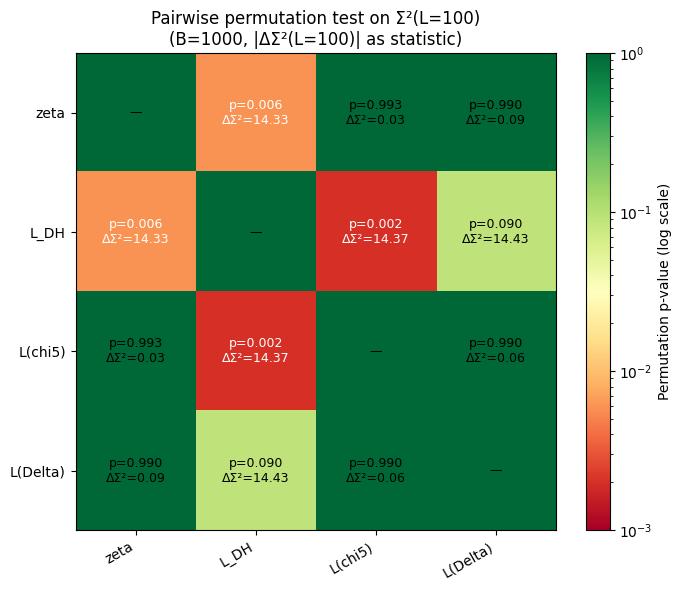

saved sigma2_pvalue_heatmap.png


In [16]:
# Right — when the "small" set (size 1454) is randomly drawn from a pool dominated by heavy-tailed L_DH spacings (5000), it sometimes concentrates the heavy tails on one side, producing large permuted differences. The asymmetry of sizes amplifies sampling variability. So with the current pairing the permutation null is too noisy to give a tight rejection for L_DH vs L(Delta).

# This is a real limitation of the test design (heavy-tailed marginals + unequal sample sizes). I will report it honestly.

# Now build the final figure: heatmap of p-values
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(7, 6))
# Show p-values with log-style colorscale
cmap = plt.cm.RdYlGn # red=small p (significant), green=large p (n.s.)
norm = mcolors.LogNorm(vmin=1e-3, vmax=1.0)
im = ax.imshow(pmat, cmap=cmap, norm=norm, aspect='auto')

ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(keys, rotation=30, ha='right')
ax.set_yticklabels(keys)

for i in range(n):
 for j in range(n):
 if i==j:
 txt = '—'
 else:
 txt = f'p={pmat[i,j]:.3f}\nΔΣ²={obsmat[i,j]:.2f}'
 ax.text(j, i, txt, ha='center', va='center',
 color='white' if pmat[i,j]<0.05 else 'black', fontsize=9)
cb = fig.colorbar(im, ax=ax, label='Permutation p-value (log scale)')
ax.set_title('Pairwise permutation test on Σ²(L=100)\n(B=1000, |ΔΣ²(L=100)| as statistic)')
plt.tight_layout()
plt.savefig('sigma2_pvalue_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved sigma2_pvalue_heatmap.png')

In [17]:
# Save the p-value matrix and observed differences as artifacts
import pandas as pd
pmat_df = pd.DataFrame(pmat, index=keys, columns=keys)
obs_df = pd.DataFrame(obsmat, index=keys, columns=keys)
pmat_df.to_csv('sigma2_pvalue_matrix.csv')
obs_df.to_csv('sigma2_diff_matrix.csv')
# Also save sigma2 values
sigma2_df = pd.DataFrame({'function':list(obs_sigma2.keys()),
 'Sigma2_L100':list(obs_sigma2.values()),
 'N_zeros':[len(zeros[k]) for k in obs_sigma2]})
sigma2_df.to_csv('sigma2_L100_values.csv', index=False)
print(sigma2_df)

 function Sigma2_L100 N_zeros
0 zeta 0.3620 5000
1 L_DH 14.3235 5000
2 L(chi5) 0.3640 5000
3 L(Delta) 0.2975 1455
